### Tools in LangGraph

We want to integrate some tools in our chatbot. We will add:

i. Calculator tool

ii. Internet search

iii. Stock price

Imp concepts to know:

i. Tool Node: this is a pre-built node in our langgraph workflow which has a list/collection of all the pre-built tools and customs tools we might have built

ii. tool_conditions: an in-built conditional edge/branch (that sits in chat_node in our START -> chat_node -> END chatbot workflow) which helps the graph decide that based on the input, should we directly just let the LLM answer with its parametric knowledge or it should call one or more tools first.

In [24]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model='gpt-4o-mini')

In [6]:
# Tools

search_tool = DuckDuckGoSearchRun(region='us-en')

@tool
def calculator(first_number: float, second_number: float, operation: str) -> dict:
    "Perform a basic arithmetic operation on two numbers. Supported operations are: add, subtract, multiply, divide."
    try:
        if operation == 'add':
            result = first_number + second_number
        elif operation == 'subtract':
            result = first_number - second_number
        elif operation == 'multiply':
            result = first_number * second_number
        elif operation == 'divide':
            if second_number == 0:
                return {"error": "Division by zero"}
            result = first_number / second_number
        else:
            return {"error": "Invalid operation"}
        
        return {'first_number': first_number, 'second_number': second_number, 'operation': operation, 'result': result}
    except Exception as e:
        return {"error": str(e)}
    
@tool
def get_stock_price(symbol: str) -> dict:
    "Fetch latest stock price for a given symbol (eg. 'AAPL), 'TSLA') using Alpha Vantage with API key in URL."

    url = f'https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=14XMRXCSLO6SEO0W'
    r = requests.get(url)
    return r.json()

In [32]:
tools = [search_tool, calculator, get_stock_price]

llm_with_tools = llm.bind_tools(tools)


In [51]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [52]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

tool_node = ToolNode(tools) # executes tool calls


In [57]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "chat_node")

# if LLM is asked for a tool, go to ToolNode, else finish
graph.add_conditional_edges("chat_node", 
                            tools_condition,  # routes to "tool_node" or "END"
                            {"tools": "tool_node", END: END})

# No need to add a separate chat_node -> END or tool_node -> END as such

# and following syntax works too
# graph.add_conditional_edges("chat_node", 
#                             tools_condition,  # routes to "tool_node" or "END"
#                             {"tools": "tool_node", "__end__": "__end__"})


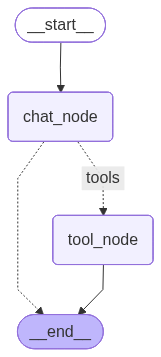

In [58]:
chatbot = graph.compile()

chatbot

In [59]:
# Regular chat
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})
print(out["messages"][-1].content)

Hello! How can I assist you today?


In [60]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 2*3?")]})
print(out["messages"][-1].content)

{"first_number": 2.0, "second_number": 3.0, "operation": "multiply", "result": 6.0}


In [61]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of apple")]})
print(out["messages"][-1].content)

{"Global Quote": {"01. symbol": "AAPL", "02. open": "313.1300", "03. high": "313.5400", "04. low": "309.6500", "05. price": "311.2300", "06. volume": "43360200", "07. latest trading day": "2026-06-04", "08. previous close": "310.2600", "09. change": "0.9700", "10. change percent": "0.3126%"}}


In [62]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="First find out the stock price of Apple using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?")]})
print(out["messages"][-1].content)

{"Global Quote": {"01. symbol": "AAPL", "02. open": "313.1300", "03. high": "313.5400", "04. low": "309.6500", "05. price": "311.2300", "06. volume": "43360200", "07. latest trading day": "2026-06-04", "08. previous close": "310.2600", "09. change": "0.9700", "10. change percent": "0.3126%"}}


Great! But one issue is, with current set up, either we go from chat_node (our LLM) to END, or tools_condition decides that we go from chat_node to tool_node, one of the many available tools is selected based on query, and the output is returned however that tool was set up to give output. In this case, we get very technical answers in JSON.

Ideally, we want that after tool_node does its proper job, we send the output back to LLM (chat_node), and after seeing our query and the proper tool answer, it will return output in plain English manner.

So just adding that edge too.

In [65]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "chat_node")

# if LLM is asked for a tool, go to ToolNode, else finish
graph.add_conditional_edges("chat_node", 
                            tools_condition,  # routes to "tool_node" or "END"
                            {"tools": "tool_node", END: END})

graph.add_edge("tool_node", "chat_node")  # this one

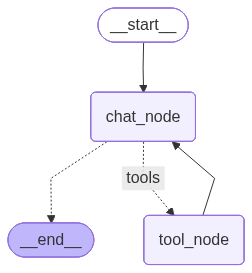

In [66]:
chatbot = graph.compile()

chatbot

In [67]:
# Regular chat
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})
print(out["messages"][-1].content)

Hello! How can I assist you today?


In [68]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 2*3?")]})
print(out["messages"][-1].content)

The result of 2 multiplied by 3 is 6.


In [69]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of apple")]})
print(out["messages"][-1].content)

The current stock price of Apple (AAPL) is $311.23.


In [70]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="First find out the stock price of Apple using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?")]})
print(out["messages"][-1].content)

The current stock price of Apple (AAPL) is $311.23. To purchase 50 shares, it would cost you $15,561.50.


Check the tracking with LangSmith too, it's interesting!